In [204]:
# Data manipulation
import pandas as pd
import numpy as np 

# Visualization
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ML
# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline #for preprocessing steps

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import collections

# Model selection
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV

# Metrics
from sklearn.metrics import (recall_score, precision_score, f1_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve, 
                             average_precision_score)

# Dealing with imbalanced dataset
from imblearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, NearMiss




In [205]:
features = pd.read_csv('raw_features.csv')
features = features.set_index('ID')
# features.info()

### raw features transformation, one-hot encoding, scaling 

In [206]:
# transform data as from the previous step:
X = features.copy()
y = X['IS_FRAUDSTER'].astype(int)


X = pd.get_dummies(X, columns=['KYC', 'TERMS_VERSION'], prefix=['kyc', 'terms_version'], dtype=int)

# 1hot-encode:
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Log:
unbounded_cols = [c for c in num_cols if X[c].max() > 1]
log_cols = [c for c in unbounded_cols if X[c].min() >= 0 and X[c].skew() > 1]
X[log_cols] = np.log1p(X[log_cols])

# Scale:
X[unbounded_cols] = RobustScaler().fit_transform(X[unbounded_cols])
X.shape

(7186, 62)

### manual undersampling

In [207]:
# Lets shuffle the data before creating the subsamples
X = X.sample(frac=1)

# amount of fraud classes 297 rows.
fraud_df = X.loc[X['IS_FRAUDSTER'] == 1]
n = X.loc[X['IS_FRAUDSTER'] == 1].shape[0]

non_fraud_df = X.loc[X['IS_FRAUDSTER'] == 0][:n]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
df_under = normal_distributed_df.sample(frac=1, random_state=42)

df_under.shape


(594, 62)

In [208]:
print('Distribution of the Classes in the subsample dataset')
print(df_under['IS_FRAUDSTER'].value_counts()/len(df_under))


Distribution of the Classes in the subsample dataset
IS_FRAUDSTER
True     0.5
False    0.5
Name: count, dtype: float64


### correlation martix

Text(0.5, 1.0, 'SubSample Correlation Matrix \n (use for reference)')

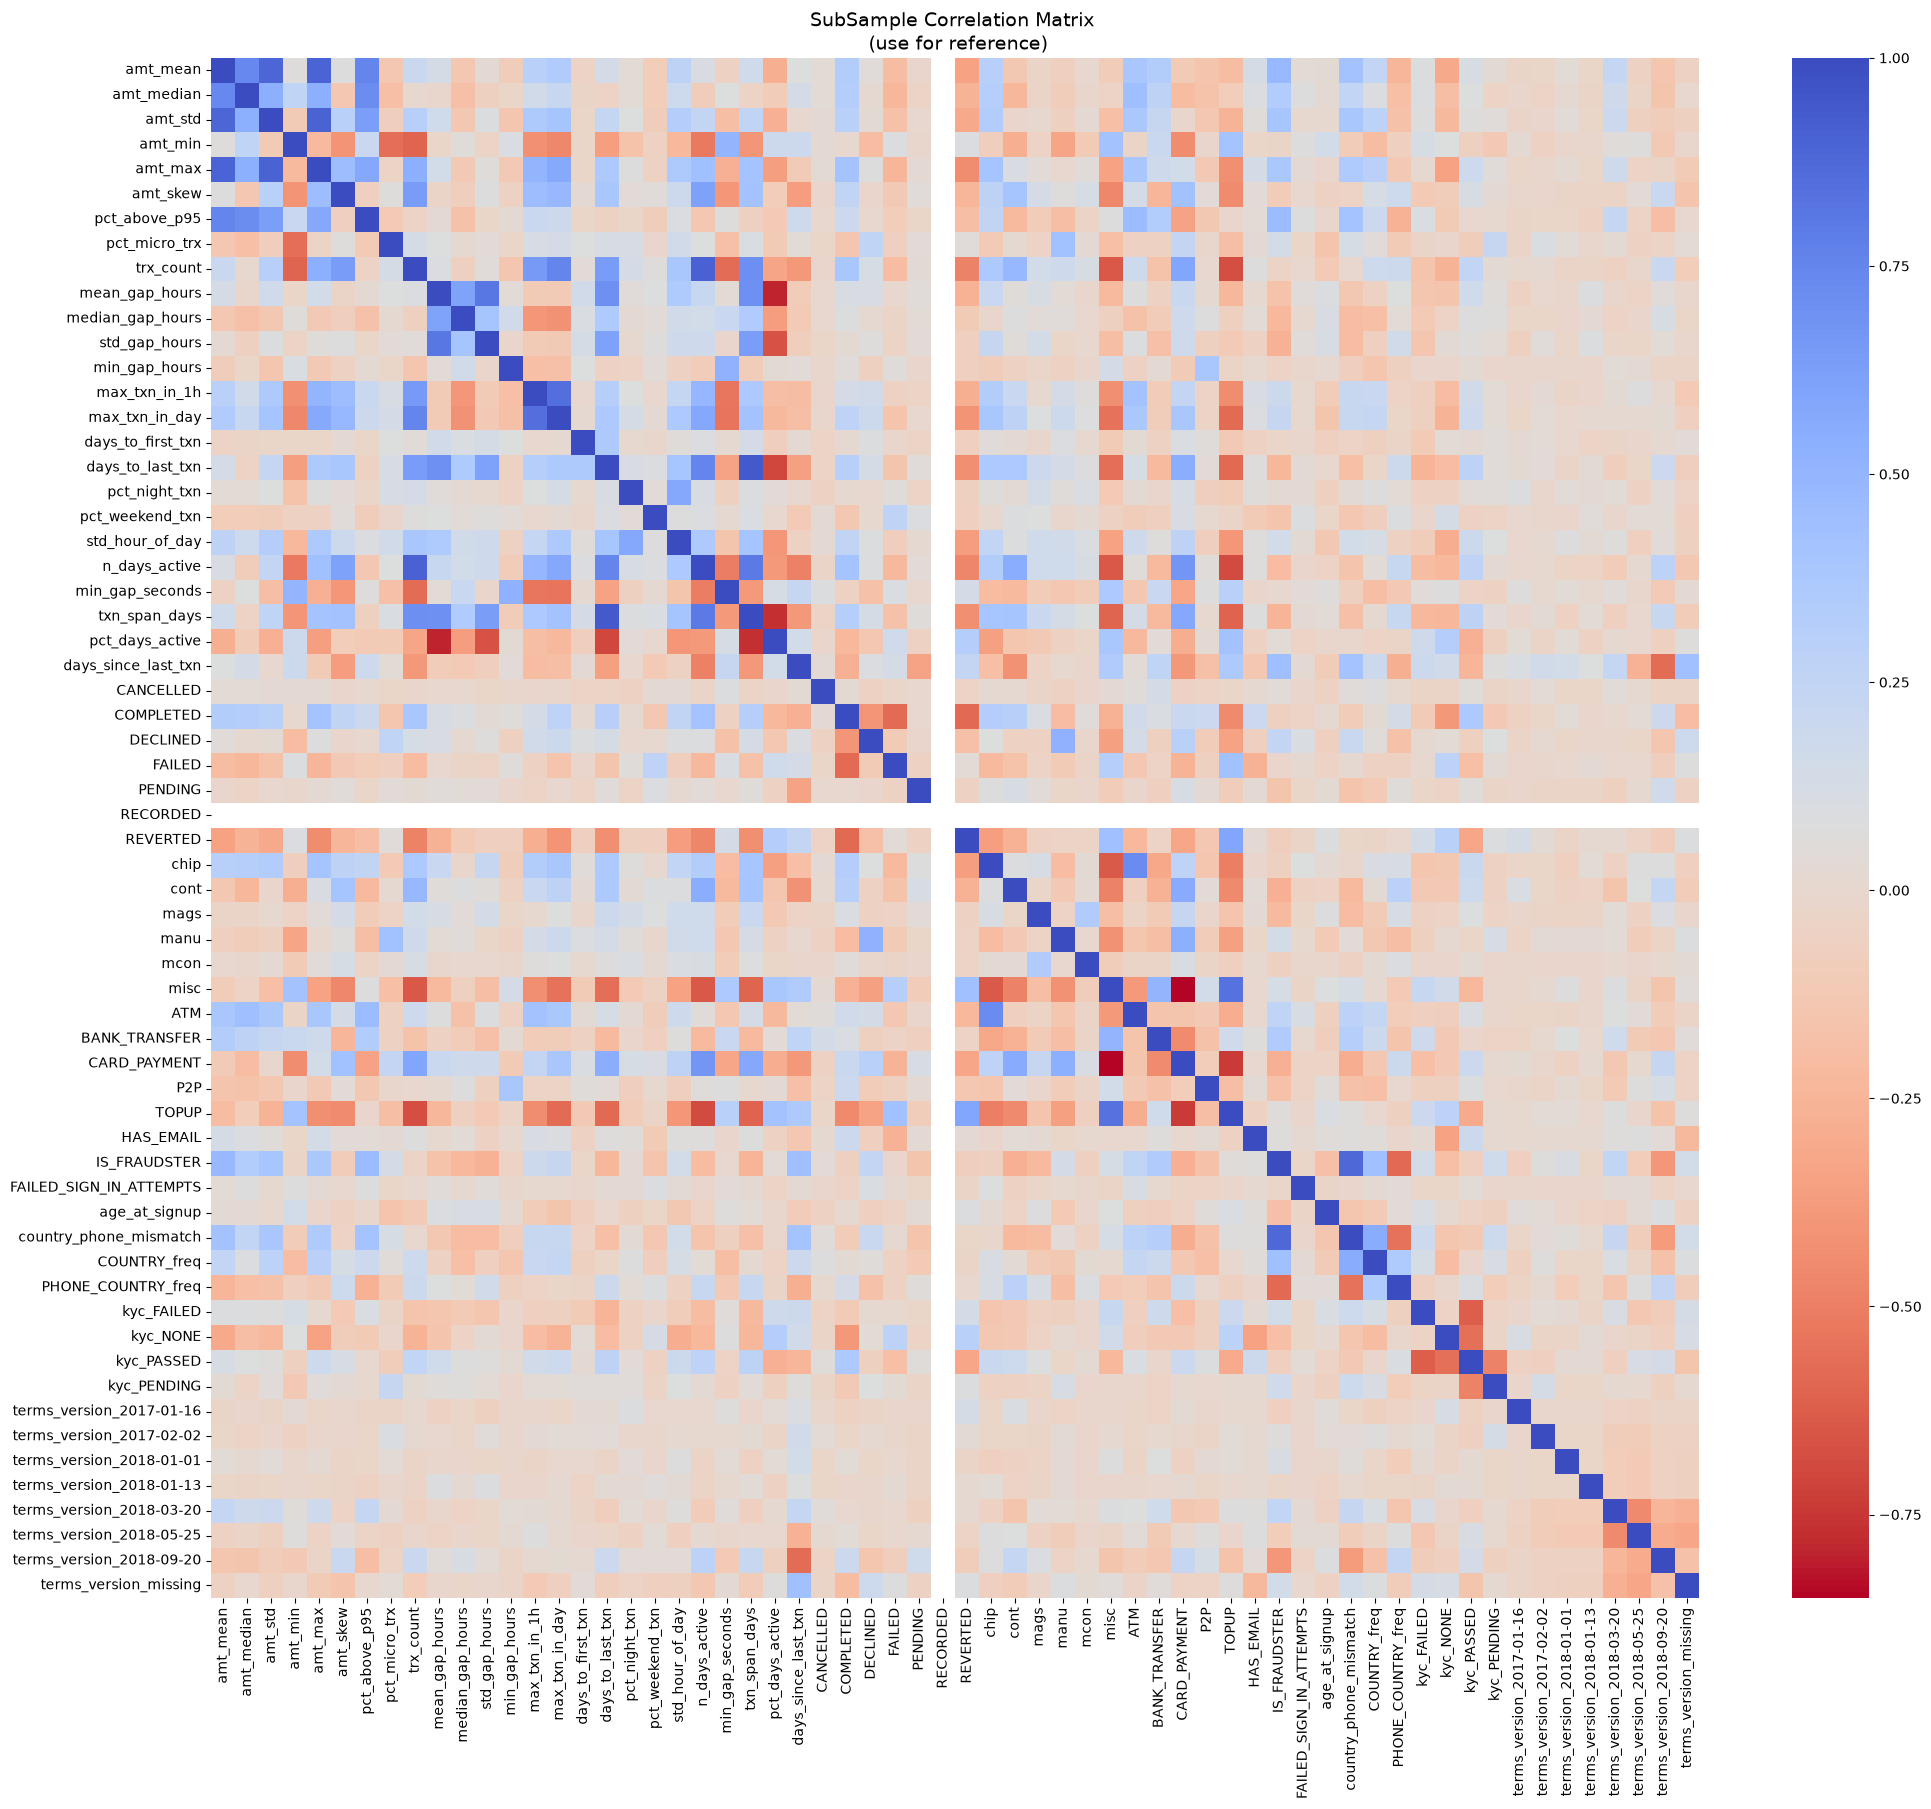

In [209]:
f, ax = plt.subplots(1, 1, figsize=(24,20))

# Make sure we use the subsample in our correlation
sub_sample_corr = df_under.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)

In [210]:
# let's check what's going on with RECORDED variable, looks like Nan with strd=0

df_under.RECORDED.unique()

array([0.])

In [211]:
df_under[['IS_FRAUDSTER', 'RECORDED']].value_counts()

IS_FRAUDSTER  RECORDED
True          0.0         297
False         0.0         297
Name: count, dtype: int64

In [212]:
# let's remove it from df:
df_under.drop('RECORDED', axis=1, inplace=True)

### correlation matrix once more

Text(0.5, 1.0, 'SubSample Correlation Matrix \n (use for reference)')

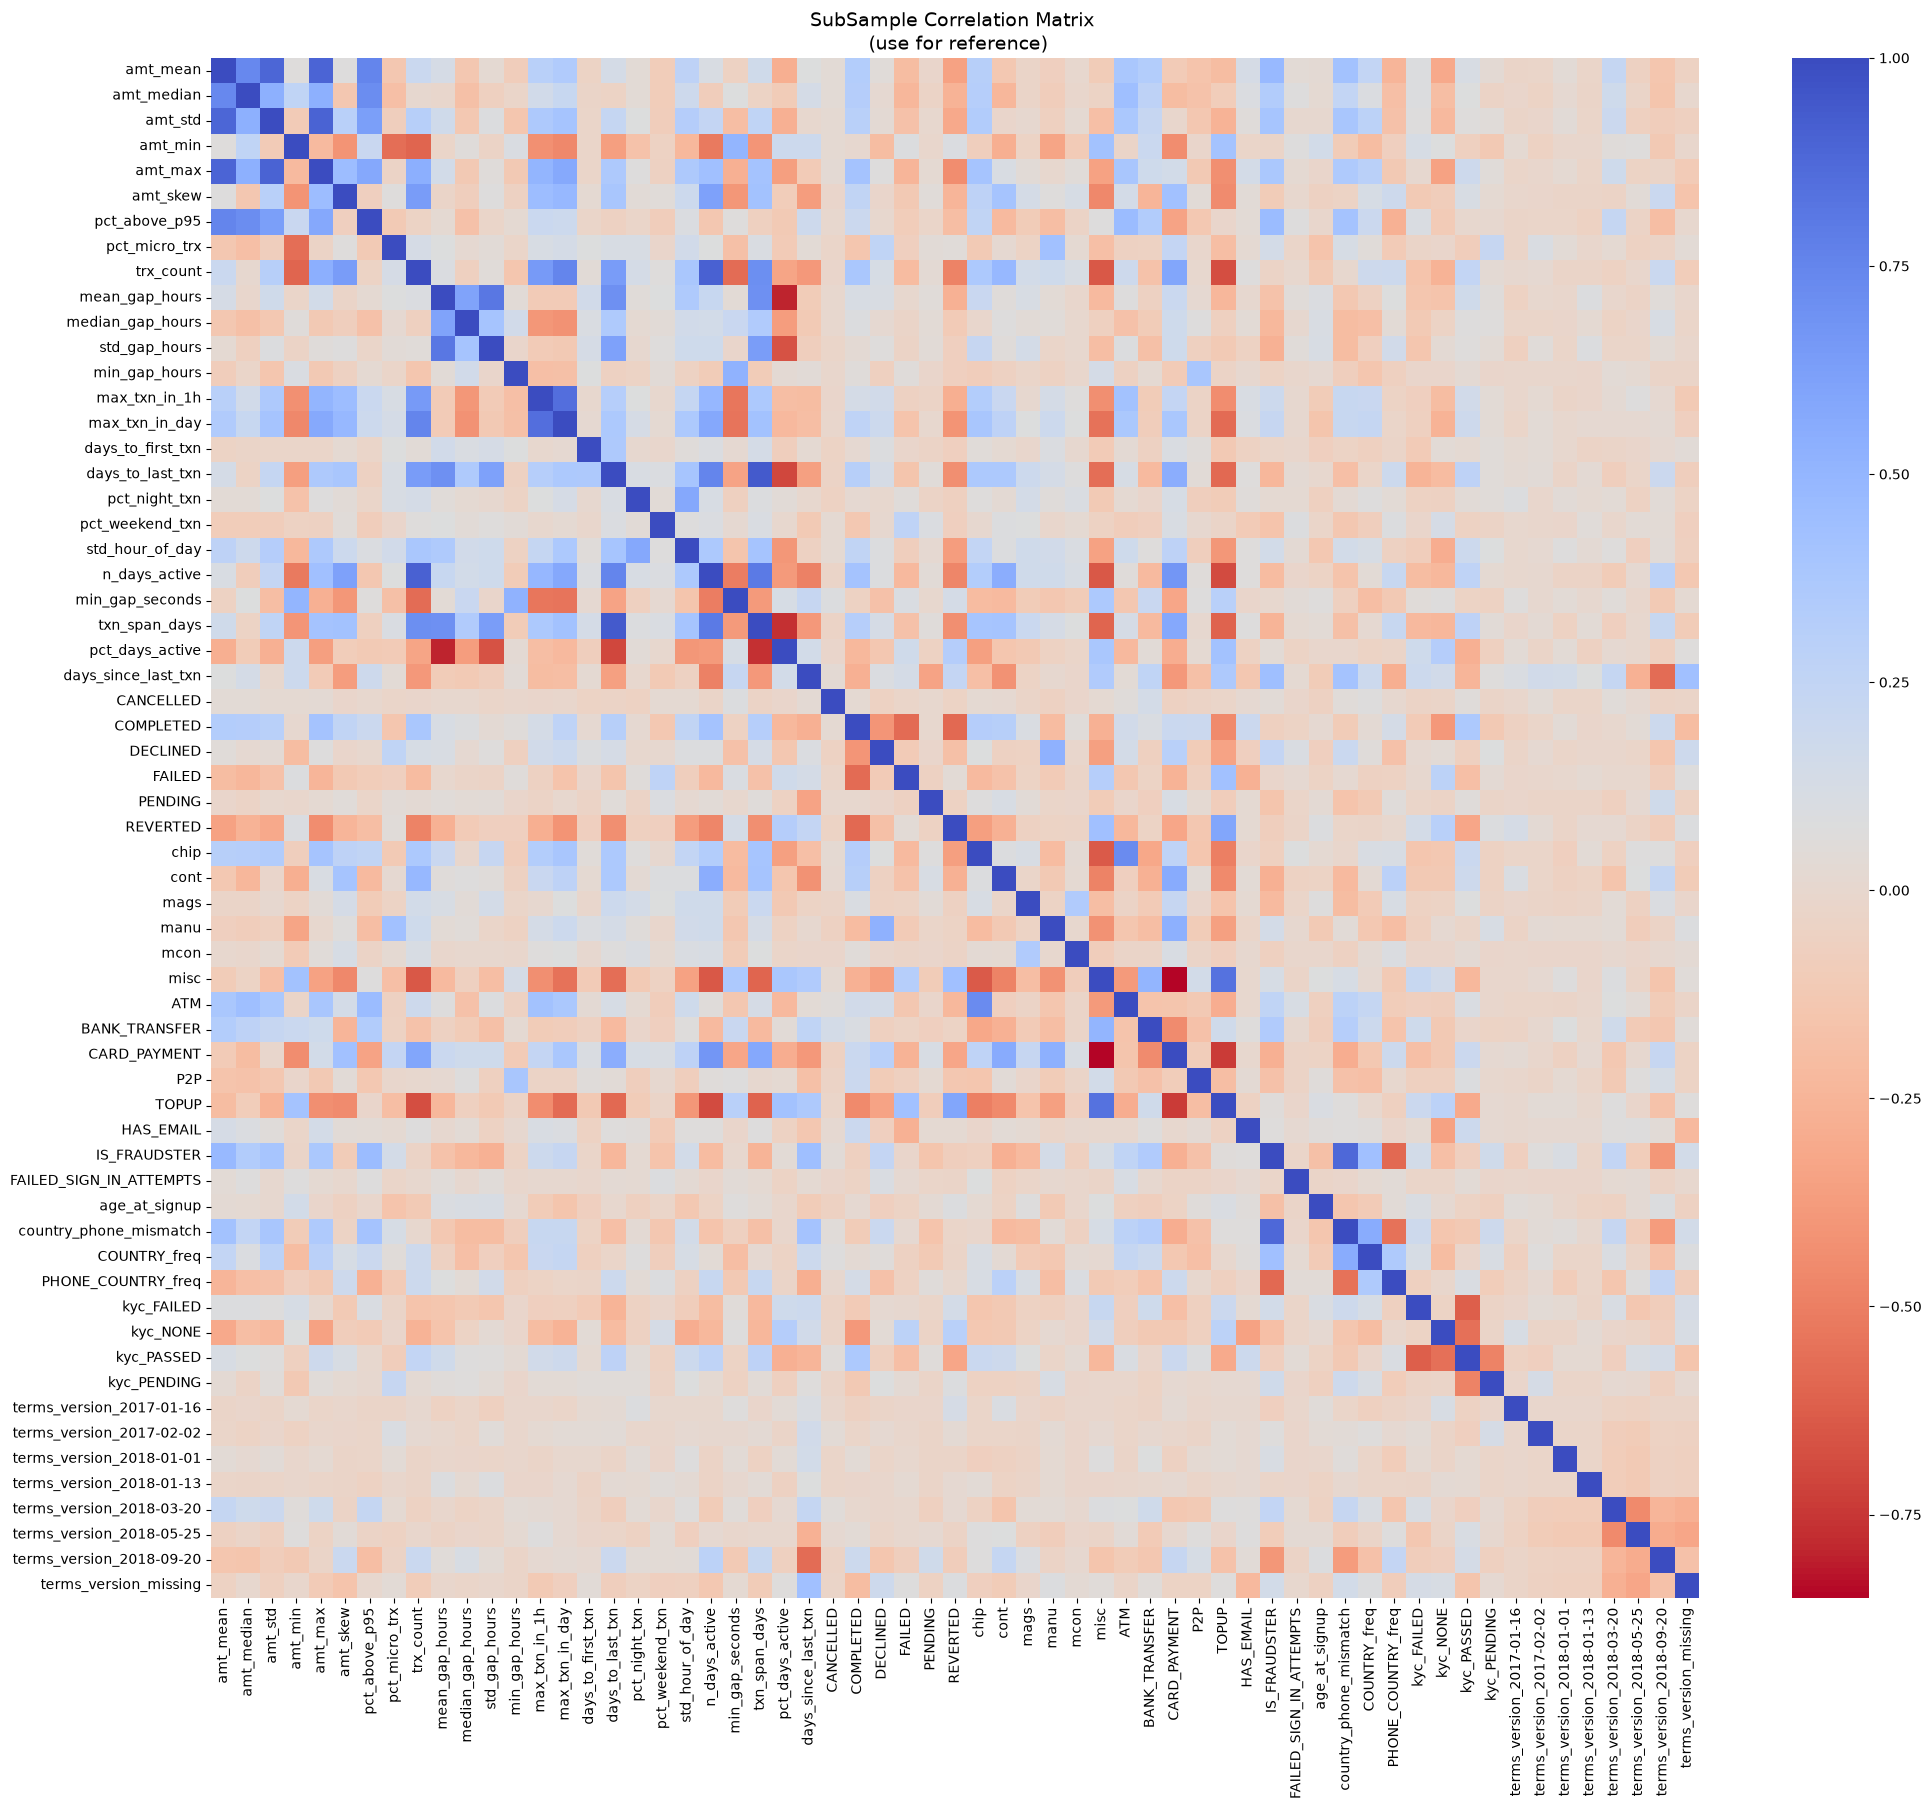

In [213]:
f, ax = plt.subplots(1, 1, figsize=(24,20))

# Make sure we use the subsample in our correlation
sub_sample_corr = df_under.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title('SubSample Correlation Matrix \n (use for reference)', fontsize=14)

In [214]:
# pairwise correlations above a threshold, upper triangle only (no self-pairs/duplicates)
corr_pairs = (
    sub_sample_corr.where(np.triu(np.ones(sub_sample_corr.shape), k=1).astype(bool))
               .stack()
               .rename('correlation')
               .reset_index()
               .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
               .dropna()
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
high_corr = corr_pairs.query('abs_correlation > 0.85').sort_values('abs_correlation', ascending=False)
high_corr

,feature_1,feature_2,correlation,abs_correlation
998,days_to_last_txn,txn_span_days,0.938419,0.938419
508,trx_count,n_days_active,0.909841,0.909841
126,amt_std,amt_max,0.902735,0.902735
4,amt_mean,amt_max,0.896637,0.896637
2,amt_mean,amt_std,0.889587,0.889587
2669,IS_FRAUDSTER,country_phone_mismatch,0.880406,0.880406
807,max_txn_in_1h,max_txn_in_day,0.854708,0.854708
2235,misc,CARD_PAYMENT,-0.850168,0.850168


In [215]:
high_corr[high_corr.feature_1=='IS_FRAUDSTER']

,feature_1,feature_2,correlation,abs_correlation
2669,IS_FRAUDSTER,country_phone_mismatch,0.880406,0.880406


FOR FUTURE: ANOMALY DETECTION FOR CORRELATED FEATURES. 

DIMENSIONALITY REDUCTION (PCA, T-SNE, SVD)

In [216]:
# New_df is from the random undersample data (fewer instances)
X_under = df_under.drop('IS_FRAUDSTER', axis=1)
y_under = df_under['IS_FRAUDSTER']

In [217]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# T-SNE Implementation
%timeit
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_under.values)

# PCA Implementation
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X_under.values)

# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X_under.values)


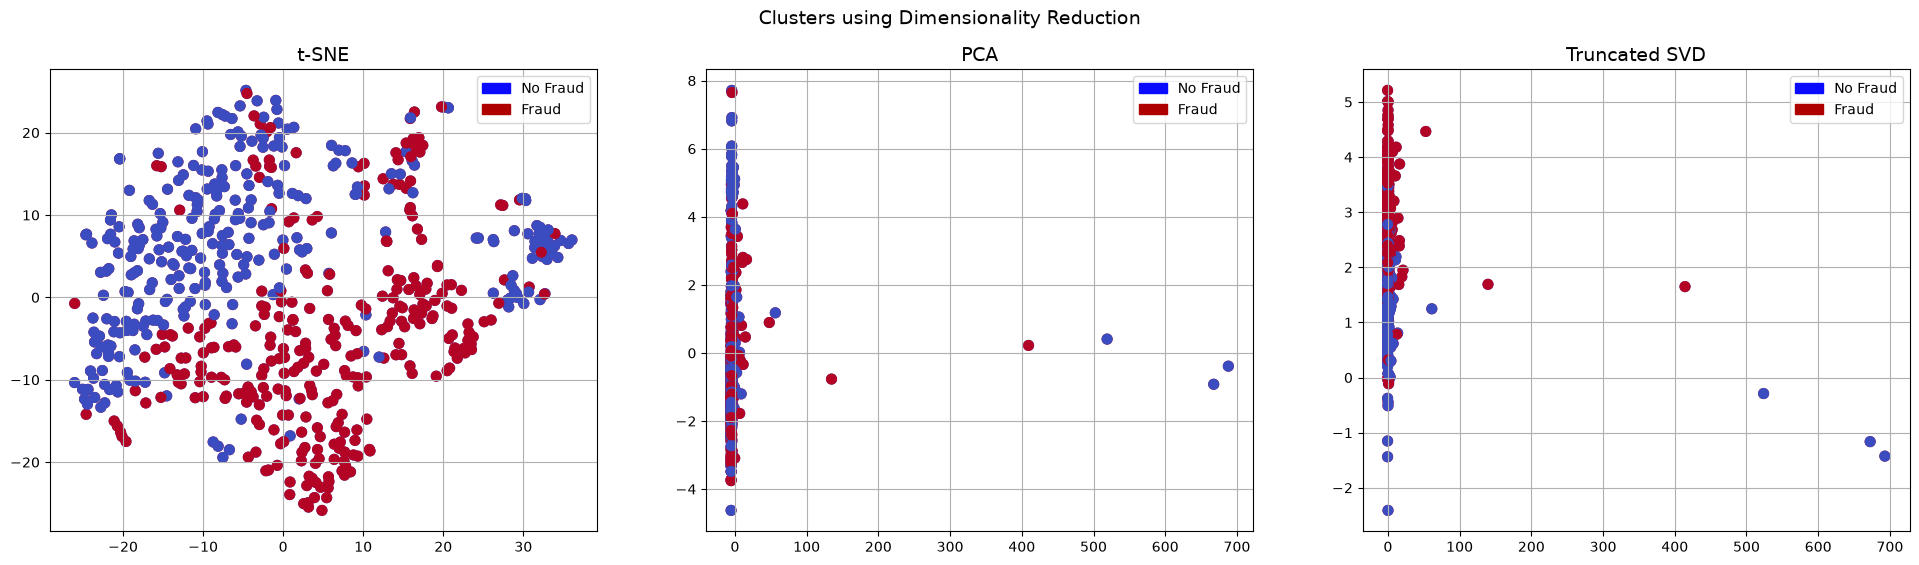

In [218]:
# import matplotlib.patches as mpatches

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y_under == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y_under == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y_under == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y_under == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y_under == 0), cmap='coolwarm', label='No Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y_under == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

In [219]:
from sklearn.model_selection import train_test_split

X_train_under_manual, X_test_under_manual, y_train_under_manual, y_test_under_manual = train_test_split(X_under, y_under, test_size=0.2)

In [220]:
X_train_under_manual.shape


(475, 60)

In [243]:
classifiers = {
    "LogisiticRegression": LogisticRegression(max_iter=1000, solver='newton-cholesky'),
    "KNearest": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(n_estimators=100, max_depth=5)
}

In [24]:
classifiers['LogisiticRegression']

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [194]:
# ?roc_auc_score

In [244]:
for name, clf in classifiers.items():
    
    clf.fit(X_train_under_manual, y_train_under_manual)
    
    y_pred = clf.predict(X_test_under_manual) 
    
    roc_auc = np.round(roc_auc_score(y_test_under_manual, y_pred)*100, 2)
    recall = np.round(recall_score(y_test_under_manual, y_pred)*100, 2)
    precision = np.round(precision_score(y_test_under_manual, y_pred)*100, 2)
    f1 = np.round(f1_score(y_test_under_manual, y_pred)*100, 2)
    
    print(f"Classifier - {name}: roc_auc={roc_auc}%, recall={recall}%, precision={precision}%, f1-score={f1}%")

Classifier - LogisiticRegression: roc_auc=94.1%, recall=91.53%, precision=96.43%, f1-score=93.91%
Classifier - KNearest: roc_auc=90.76%, recall=91.53%, precision=90.0%, f1-score=90.76%
Classifier - DecisionTreeClassifier: roc_auc=94.1%, recall=91.53%, precision=96.43%, f1-score=93.91%
Classifier - RandomForestClassifier: roc_auc=97.46%, recall=94.92%, precision=100.0%, f1-score=97.39%
Classifier - GradientBoostingClassifier: roc_auc=94.1%, recall=91.53%, precision=96.43%, f1-score=93.91%


In [ ]:
# let's do some crossvalidation to challenge these too beautiful results. 

### crossvalidation


In [245]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    
    training_score = cross_validate(clf, X_train_under_manual, y_train_under_manual, cv=cv, scoring=['precision', 'recall', 'f1'])
    
    roc_auc = np.round(roc_auc_score(y_test_under_manual, y_pred)*100, 2)
    precision=round(training_score['test_precision'].mean(), 2)*100
    recall=round(training_score['test_recall'].mean(), 2)*100
    f1 = round(training_score['test_f1'].mean(), 2)*100
    
    print(f"Classifier - {name}: recall={recall}%, precision={precision}%, f1-score={f1}%")

Classifier - LogisiticRegression: recall=96.0%, precision=96.0%, f1-score=96.0%
Classifier - KNearest: recall=89.0%, precision=91.0%, f1-score=90.0%
Classifier - DecisionTreeClassifier: recall=94.0%, precision=90.0%, f1-score=92.0%
Classifier - RandomForestClassifier: recall=97.0%, precision=99.0%, f1-score=98.0%
Classifier - GradientBoostingClassifier: recall=93.0%, precision=95.0%, f1-score=94.0%


In [ ]:
# on CV even better 
# looks very suspicious. let's assume data leakage. but where?
# 2 points of data leakage: scaling and undersampling before CV. 
# during the scaling we computing statistics in data that shouldn't be touched
# during undersampling the distribution of test set was changes, but in production there is no such situationas 50/50 frauds/no_frauds.
# so we have to undersample during cross-validation. first split the data on train/test sets. 
# Than undersample only train set, and keep the test set as it is. 

In [118]:
# cat_cols = ['KYC', 'TERMS_VERSION']

# X_raw = features.drop(columns=['IS_FRAUDSTER', 'RECORDED'])  # RECORDED was constant/leaky, see EDA above
# y_raw = features['IS_FRAUDSTER'].astype(int)

# X_raw = pd.get_dummies(X_raw, columns=cat_cols, prefix=['kyc', 'terms_version'], dtype=int)

# # 1hot-encode:
# num_cols = X_raw.select_dtypes(include=np.number).columns
# X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

# # Log:
# unbounded_cols = [c for c in num_cols if X_raw[c].max() > 1]
# log_cols = [c for c in unbounded_cols if X_raw[c].min() >= 0 and X_raw[c].skew() > 1]
# X_raw[log_cols] = np.log1p(X_raw[log_cols])

# # Scale:
# X_raw[unbounded_cols] = RobustScaler().fit_transform(X_raw[unbounded_cols])
# X_raw.shape

https://imbalanced-learn.org/stable/under_sampling.html


https://www.comet.com/site/blog/resampling-to-properly-handle-imbalanced-datasets-in-machine-learning/

# undersampling techniques

In [246]:
cat_cols = ['KYC', 'TERMS_VERSION']

X_raw = features.drop(columns=['IS_FRAUDSTER', 'RECORDED'])  # RECORDED was constant/leaky, see EDA above
y_raw = features['IS_FRAUDSTER'].astype(int)

numeric_cols = [c for c in X_raw.columns if c not in cat_cols]

In [247]:
# We will undersample during cross validating
# Split on train/test 
X_temp_under, X_test_under, y_temp_under, y_test_under = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)
# put aside 'test' for real test and split 'train' once more on train/test for undersampling crossvalidation. 
X_train_under, X_val_under, y_train_under, y_val_under = train_test_split(
    X_temp_under,
    y_temp_under,
    test_size=0.25,
    random_state=42,
    stratify=y_temp_under
)



In [ ]:
classifiers = {
    "LogisiticRegression": LogisticRegression(max_iter=1000, solver='liblinear'), #solver='newton-cholesky', changed from lbfgs, small n_samples >> n_features)
    "KNearest": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(n_estimators=100, max_depth=5)
}
# 

### cross validation + undersampling

#### RandomUnderSampler

In [249]:
numeric_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', RobustScaler()),
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

In [250]:
for name, clf in classifiers.items():
    pipe = ImbPipeline([
        ('preprocess', preprocess),            # ColumnTransformer: impute+scale numeric, one-hot cat
        ('undersample', RandomUnderSampler(random_state=42)),
        ('clf', clf),
    ])

    scores = cross_validate(pipe, X_train_under, y_train_under, cv=cv, scoring=['roc_auc', 'precision', 'recall', 'f1'])
    
    roc_auc = np.round(scores['test_roc_auc'].mean() * 100, 2)
    precision = np.round(scores['test_precision'].mean() * 100, 2)
    recall = np.round(scores['test_recall'].mean() * 100, 2)
    f1 = np.round(scores['test_f1'].mean() * 100, 2)

    print(f"Classifier - {name}: roc_auc={roc_auc}%, recall={recall}%, precision={precision}%, f1-score={f1}%")

Classifier - LogisiticRegression: roc_auc=98.45%, recall=96.1%, precision=42.15%, f1-score=58.4%
Classifier - KNearest: roc_auc=85.25%, recall=75.44%, precision=14.78%, f1-score=24.69%
Classifier - DecisionTreeClassifier: roc_auc=93.87%, recall=93.84%, precision=40.78%, f1-score=56.6%
Classifier - RandomForestClassifier: roc_auc=99.55%, recall=95.51%, precision=64.35%, f1-score=76.85%
Classifier - GradientBoostingClassifier: roc_auc=97.56%, recall=94.38%, precision=44.09%, f1-score=59.62%


### gridsearch + cross validation + undersampling

In [251]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "LogisiticRegression": {'clf__C': [0.01, 0.1, 1, 10]},
    "KNearest": {'clf__n_neighbors': [3, 5, 7, 11]},
    "DecisionTreeClassifier": {'clf__max_depth': [3, 5, 8, None], 'clf__min_samples_leaf': [1, 5, 10]},
    "RandomForestClassifier": {'clf__n_estimators': [100, 300], 'clf__max_depth': [5, 10, None]},
    "GradientBoostingClassifier": {'clf__n_estimators': [100, 200], 'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]},
}


### RandomUnderSampler

In [252]:
classifiers

{'LogisiticRegression': LogisticRegression(max_iter=1000, solver='liblinear'),
 'KNearest': KNeighborsClassifier(),
 'DecisionTreeClassifier': DecisionTreeClassifier(),
 'RandomForestClassifier': RandomForestClassifier(n_jobs=-1),
 'GradientBoostingClassifier': GradientBoostingClassifier(max_depth=5)}

In [253]:
best_estimators_random = {}
results_random = []

for name, clf in classifiers.items():
    pipe = ImbPipeline([
        ('preprocess', preprocess),
        ('undersample', RandomUnderSampler()),
        ('clf', clf),
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    
    grid.fit(X_train_under, y_train_under)
    best_estimators_random[name] = grid.best_estimator_

    y_pred = grid.predict(X_val_under)
    
    roc_auc = np.round(roc_auc_score(y_val_under, y_pred) * 100, 2)
    recall = np.round(recall_score(y_val_under, y_pred) * 100, 2)
    precision = np.round(precision_score(y_val_under, y_pred) * 100, 2)
    f1 = np.round(f1_score(y_val_under, y_pred) * 100, 2)

    results_random.append({
        'classifier': name,
        'best_params': grid.best_params_,
        'cv_f1': round(grid.best_score_, 3),
        
        'test_roc_auc': roc_auc,
        'test_recall': recall,
        'test_precision': precision,
        'test_f1': f1,
    })

pd.DataFrame(results_random)

,classifier,best_params,cv_f1,test_roc_auc,test_recall,test_precision,test_f1
0,LogisiticRegression,{'clf__C': 1},0.590,95.98,96.61,47.11,63.33
1,KNearest,{'clf__n_neighbors': 11},0.275,76.47,69.49,15.24,25.00
2,DecisionTreeClassifier,"{'clf__max_depth': 3, 'clf__min_samples_leaf': 1}",0.683,89.67,83.05,49.00,61.64
3,RandomForestClassifier,"{'clf__max_depth': 10, 'clf__n_estimators': 100}",0.821,96.66,94.92,71.79,81.75
4,GradientBoostingClassifier,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.734,95.45,93.22,63.22,75.34


### NearMiss


In [ ]:
# 1. computes the distance (usually Euclidean distance) between the majority class and minority class instances.
# 2. retains specific majority class examples based on one of three distinct rule sets (Versions):
# NearMiss-1: Selects majority class examples that have the smallest average distance to the 3 closest minority class examples. 
# It focuses heavily on borderline majority points.
# NearMiss-2: Selects majority class examples that have the smallest average distance to the 3 furthest minority class examples. 
# This ensures the retained majority points are spread out and cover the outer edge of the minority distribution.
# NearMiss-3: Selects a predefined number of closest majority class examples for each minority class sample. 


In [254]:
best_estimators_nm = {}
results_nm = []


for name, clf in classifiers.items():
    pipe = ImbPipeline([
        ('preprocess', preprocess),
        ('undersample', NearMiss(sampling_strategy='majority')),
        ('clf', clf),
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train_under, y_train_under)
    best_estimators_nm[name] = grid.best_estimator_

    y_pred = grid.predict(X_test_under)
    recall = np.round(recall_score(y_test_under, y_pred) * 100, 2)
    precision = np.round(precision_score(y_test_under, y_pred) * 100, 2)
    f1 = np.round(f1_score(y_test_under, y_pred) * 100, 2)

    results_nm.append({
        'classifier': name,
        'best_params': grid.best_params_,
        'cv_f1': round(grid.best_score_, 3),
        'test_recall': recall,
        'test_precision': precision,
        'test_f1': f1,
    })

pd.DataFrame(results_nm)

,classifier,best_params,cv_f1,test_recall,test_precision,test_f1
0,LogisiticRegression,{'clf__C': 10},0.170,98.31,8.84,16.22
1,KNearest,{'clf__n_neighbors': 11},0.179,83.05,9.61,17.22
2,DecisionTreeClassifier,"{'clf__max_depth': 3, 'clf__min_samples_leaf': 1}",0.348,94.92,16.18,27.65
3,RandomForestClassifier,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.244,98.31,11.46,20.53
4,GradientBoostingClassifier,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.398,98.31,19.66,32.77


In [255]:
best_estimators_random_boot = {}
results_random_boot = []

for name, clf in classifiers.items():
    pipe = ImbPipeline([
        ('preprocess', preprocess),
        ('undersample', RandomUnderSampler(replacement=True)),
        ('clf', clf),
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train_under, y_train_under)
    best_estimators_random_boot[name] = grid.best_estimator_

    y_pred = grid.predict(X_test_under)
    recall = np.round(recall_score(y_test_under, y_pred) * 100, 2)
    precision = np.round(precision_score(y_test_under, y_pred) * 100, 2)
    f1 = np.round(f1_score(y_test_under, y_pred) * 100, 2)

    results_random_boot.append({
        'classifier': name,
        'best_params': grid.best_params_,
        'cv_f1': round(grid.best_score_, 3),
        'test_recall': recall,
        'test_precision': precision,
        'test_f1': f1,
    })

pd.DataFrame(results_random_boot)

,classifier,best_params,cv_f1,test_recall,test_precision,test_f1
0,LogisiticRegression,{'clf__C': 1},0.548,96.61,55.88,70.81
1,KNearest,{'clf__n_neighbors': 11},0.266,72.88,14.58,24.29
2,DecisionTreeClassifier,"{'clf__max_depth': 3, 'clf__min_samples_leaf': 1}",0.720,88.14,59.09,70.75
3,RandomForestClassifier,"{'clf__max_depth': 10, 'clf__n_estimators': 300}",0.808,94.92,71.79,81.75
4,GradientBoostingClassifier,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.781,93.22,61.80,74.32


### Learning curves for best estimators

In [273]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

In [325]:
def plot_learning_curve(train_sizes, train_scores, test_scores, model, score='f1'):
    
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color="#ff3324",
             label="Training score")
    plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', color="#da24ff",
                label="Cross-validation score")

    plt.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.1, color="#ff3324")
    plt.fill_between(train_sizes, test_scores.mean(1)-test_scores.std(1), test_scores.mean(1)+test_scores.std(1), alpha=0.1, color="#da24ff")

    plt.title(f"{model} \n Learning Curve", fontsize=14)
    plt.xlabel('train size'); 
    plt.ylabel(f'{score}'); 
    plt.legend()
    plt.grid(True)

    return plt

<module 'matplotlib.pyplot' from '/Users/natallialantukh/Desktop/projects/fraud_detection_revolut/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

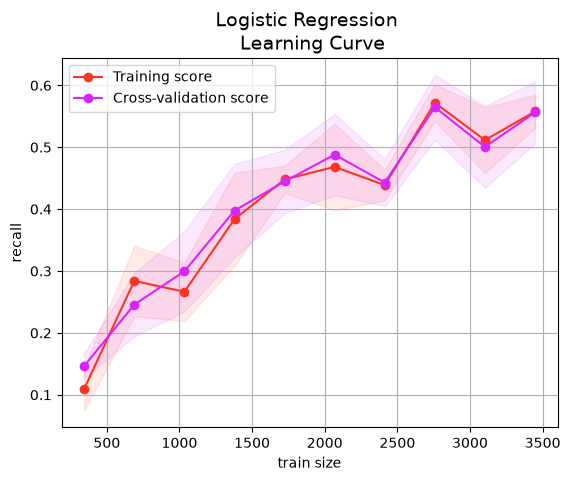

In [359]:
from sklearn.model_selection import learning_curve
from sklearn.base import clone

# reuse the tuned pipeline from GridSearchCV (preprocess + undersample + clf with best C)
lr_pipe = clone(best_estimators_random_boot['LogisiticRegression'])

train_sizes_lr, train_scores_lr, test_scores_lr = learning_curve(
    lr_pipe,
    X_train_under, y_train_under,   # the IMBALANCED split fed into grid.fit(), not already-undersampled data
    cv=cv,                           # same StratifiedKFold(5) used for the grid search
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)


plot_learning_curve(train_sizes_lr, train_scores_lr, test_scores_lr, model='Logistic Regression', score='recall')

In [ ]:
X_raw.shape


(7186, 50)

<module 'matplotlib.pyplot' from '/Users/natallialantukh/Desktop/projects/fraud_detection_revolut/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

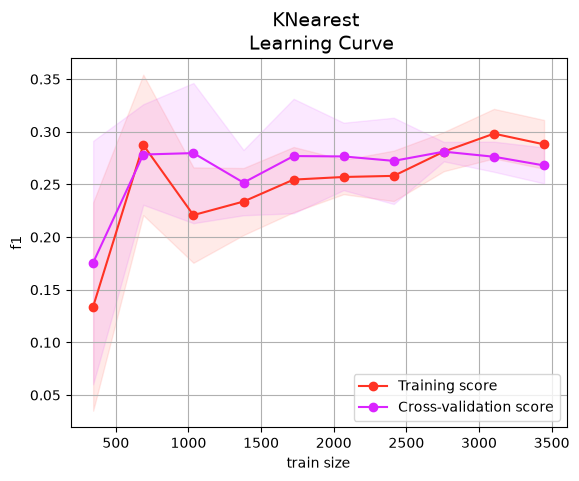

In [358]:
knn_pipe = clone(best_estimators_random_boot['KNearest'])

train_sizes_knn, train_scores_knn, test_scores_knn = learning_curve(
    knn_pipe,
    X_train_under, y_train_under,   # the IMBALANCED split fed into grid.fit(), not already-undersampled data
    cv=cv,                           # same StratifiedKFold(5) used for the grid search
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)
plot_learning_curve(train_sizes_knn, train_scores_knn, test_scores_knn, model='KNearest', score='f1')

'GradientBoostingClassifier'

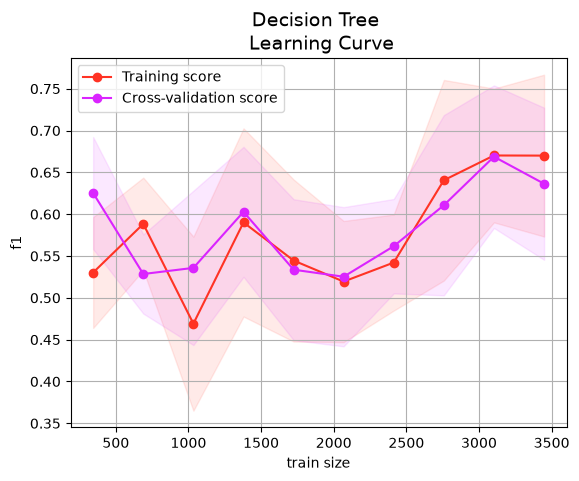

In [357]:
dt_pipe = clone(best_estimators_random_boot['DecisionTreeClassifier'])

train_sizes_dt, train_scores_rf, test_scores_dt = learning_curve(
    dt_pipe,
    X_train_under, y_train_under,   # the IMBALANCED split fed into grid.fit(), not already-undersampled data
    cv=cv,                           # same StratifiedKFold(5) used for the grid search
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)
plot_learning_curve(train_sizes_dt, train_scores_rf, test_scores_dt, model='Decision Tree', score='f1')

'DecisionTreeClassifier'

'GradientBoostingClassifier'

<module 'matplotlib.pyplot' from '/Users/natallialantukh/Desktop/projects/fraud_detection_revolut/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

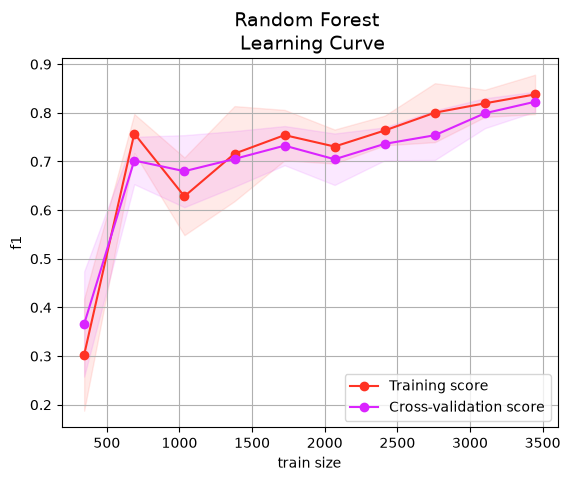

In [356]:
rf_pipe = clone(best_estimators_random_boot['RandomForestClassifier'])

train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    rf_pipe,
    X_train_under, y_train_under,   # the IMBALANCED split fed into grid.fit(), not already-undersampled data
    cv=cv,                           # same StratifiedKFold(5) used for the grid search
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)
plot_learning_curve(train_sizes_rf, train_scores_rf, test_scores_rf, model='Random Forest', score='f1')


<module 'matplotlib.pyplot' from '/Users/natallialantukh/Desktop/projects/fraud_detection_revolut/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

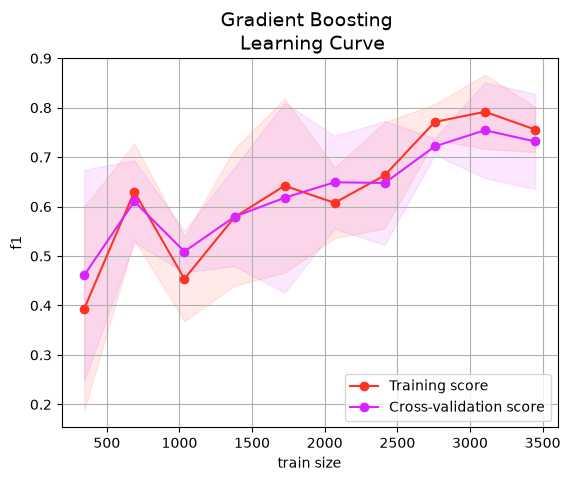

In [355]:
gb_pipe = clone(best_estimators_random_boot['GradientBoostingClassifier'])

train_sizes_gb, train_scores_gb, test_scores_gb = learning_curve(
    gb_pipe,
    X_train_under, y_train_under,   # the IMBALANCED split fed into grid.fit(), not already-undersampled data
    cv=cv,                           # same StratifiedKFold(5) used for the grid search
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)
plot_learning_curve(train_sizes_gb, train_scores_gb, test_scores_gb, model='Gradient Boosting', score='f1')


In [ ]:
# from imblearn.under_sampling import RandomUnderSampler

# X_temp_under, X_test_under, y_temp_under, y_test_under = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

# X_train_under, X_val_under, y_train_under, y_val_under = train_test_split(
#     X_temp_under,
#     y_temp_under,
#     test_size=0.25,
#     random_state=42,
#     stratify=y_temp_under
# )

# rus_under = RandomUnderSampler(random_state=42)
# X_train_balanced_under, y_train_balanced_under = rus_under.fit_resample(X_train_under, y_train_under)

# rf_balanced_under = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )
# rf_balanced_under.fit(X_train_balanced_under, y_train_balanced_under)

# y_prob_val_under = rf_balanced_under.predict_proba(X_val_under)[:, 1]
# y_prob_test_under = rf_balanced_under.predict_proba(X_test_under)[:, 1]

# print(f"Train set: {len(X_train_under)} → Balanced: {len(X_train_balanced_under)}")
# print(f"Validation set: {len(X_val_under)} ({y_val_under.sum()} fraudsters)")
# print(f"Test set: {len(X_test_under)} ({y_test_under.sum()} fraudsters)")
# print(f"\nValidation ROC-AUC: {roc_auc_score(y_val_under, y_prob_val_under):.4f}")
# print(f"Test ROC-AUC: {roc_auc_score(y_test_under, y_prob_test_under):.4f}")

Train set: 4311 → Balanced: 358
Validation set: 1437 (59 fraudsters)
Test set: 1438 (59 fraudsters)

Validation ROC-AUC: 0.9939
Test ROC-AUC: 0.9954


In [281]:
test_scores.mean(axis=1)

array([0.14204851, 0.25362927, 0.29122946, 0.3835839 , 0.49274653,
       0.46100833, 0.44004918, 0.52409053, 0.57322009, 0.57783347])

In [ ]:

def plot_learning_curve(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)
    # First Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator1, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Training size (m)')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")
    
    # Second Estimator 
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Training size (m)')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")
    
    # Third Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")
    
    # Fourth Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")
    return plt

In [ ]:
# cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
# plot_learning_curve(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, (0.87, 1.01), cv=cv, n_jobs=4)

In [95]:
# random undersampling gives a little worse recall (2-3%), BUT NearMiss gives quit unacceptable precision. 
# Although I previously made assimption that recall is more important for this business, 
# If we start block cards and annoy customers with other security alerts the churn rate could surge. 
# Let's check auc

In [257]:
y_final_under = best_estimators_random_boot['RandomForestClassifier'].predict(X_val_under)

In [157]:
# y_val_under[y_val_under==1]

In [259]:
tp = sum(y_final_under[y_val_under==1]==1)
fp = sum( y_final_under[y_val_under==0]==1)
fn = sum( y_final_under[y_val_under==1]==0)


In [263]:
recall = np.round(tp/(tp + fn)*100, 2)
precision = np.round(tp/(tp + fp)*100, 2)
f1 = np.round(2 * recall * precision/(recall+precision), 2)
print(f"f1-sore = {f1}")
print(f"recall = {recall}")
print(f"precision = {precision}")

f1-sore = 79.41
recall = 91.53
precision = 70.13


In [ ]:
# for undersampling the best estimator RandomForestClassifier with random undersampling with replacement (bootstraping)
# mixed up the test/val datasets, crossvalidated on test (consistently through all sampling techniques, and final evaluation on X_val)

In [ ]:
# want to come back to preundersampling state and try Pipeline with gridsearch+cv on unbalanced data. 
# Smote or not to smote?


https://arxiv.org/abs/2201.08528


In [ ]:
# add AUC as the main metrick. 